# Time-Adjusted Cluster Load Allocation with Error Correction in Sparsely Metered Distribution Networks

This notebook implements the complete research pipeline for sparsely sampled distribution system state estimation, Cluster Load Allocation (CLA), and transient-assisted error correction.

In [1]:
# ----------------------------------------------------------------------------- 
# DSSE / ATP-EMTP research environment setup 
# 
# Installs: 
#   - Wine + i386 support for Windows ATP-EMTP binaries 
#   - DSSE repository 
#   - text_data_cards dependency required by pyATP 
#   - pyATP (atp-utils) 
#   - OpenDSS / DSS-Extensions 
#   - scientific Python stack 
# ----------------------------------------------------------------------------- 
 
import os 
import sys 
import site 
import subprocess 
from pathlib import Path 
 
# ----------------------------------------------------------------------------- 
# 1. Wine 
# ----------------------------------------------------------------------------- 
 
try: 
    subprocess.run( 
        ["wine", "--version"], 
        check=True, 
        capture_output=True, 
        text=True, 
    ) 
    print("Wine is already installed on the research runtime.") 
 
except (FileNotFoundError, subprocess.CalledProcessError): 
    print("Wine is missing. Installing Wine and i386 multiarch support...") 
 
    subprocess.run( 
        "sudo dpkg --add-architecture i386", 
        shell=True, 
        check=True, 
    ) 
 
    subprocess.run( 
        "sudo apt-get update", 
        shell=True, 
        check=True, 
    ) 
 
    subprocess.run( 
        [ 
            "sudo", 
            "env", 
            "DEBIAN_FRONTEND=noninteractive", 
            "apt-get", 
            "-y", 
            "--no-install-recommends", 
            "install", 
            "wine", 
            "wine32:i386", 
        ], 
        check=True, 
    ) 
 
    print("Wine successfully installed.") 
 
 
# ----------------------------------------------------------------------------- 
# 2. Repository configuration 
# ----------------------------------------------------------------------------- 
 
REPO_URL = "https://github.com/mhizterpaul/dsse.git" 
 
PYATP_URL = "https://github.com/pdb5627/pyATP.git" 
 
TEXT_DATA_CARDS_URL = ( 
    "https://github.com/pdb5627/text_data_cards.git" 
) 
 
# ----------------------------------------------------------------------------- 
# 3. Locate / clone DSSE repository 
# ----------------------------------------------------------------------------- 
 
if not os.path.exists("src"): 
 
    target_dir = None 
 
    if os.path.exists("/content"): 
        # Google Colab 
        target_dir = "/content/dsse" 
 
    elif os.path.exists("/kaggle/working"): 
        # Kaggle 
        target_dir = "/kaggle/working/dsse" 
 
    if target_dir: 
 
        if not os.path.exists(target_dir): 
            subprocess.run( 
                ["git", "clone", REPO_URL, target_dir], 
                check=True, 
            ) 
 
        os.chdir(target_dir) 
 
 
# ----------------------------------------------------------------------------- 
# 4. Make repository importable 
# ----------------------------------------------------------------------------- 
 
cwd = os.getcwd() 
 
if cwd not in sys.path: 
    sys.path.insert(0, cwd) 
 
print(f"Current working directory: {cwd}") 
 
 
# ----------------------------------------------------------------------------- 
# 5. Determine external package directories 
# ----------------------------------------------------------------------------- 
 
if os.path.exists("/kaggle/working"): 
 
    pyatp_dir = Path("/kaggle/working/pyATP") 
    text_data_cards_dir = Path("/kaggle/working/text_data_cards") 
 
elif os.path.exists("/content"): 
 
    pyatp_dir = Path("/content/pyATP") 
    text_data_cards_dir = Path("/content/text_data_cards") 
 
else: 
 
    pyatp_dir = Path.home() / "dev" / "pyATP" 
    text_data_cards_dir = Path.home() / "dev" / "text_data_cards" 
 
 
# ----------------------------------------------------------------------------- 
# 6. Clone + install text_data_cards 
# 
# pyATP declares: 
# 
#     text-data-cards 
# 
# text_data_cards itself declares: 
# 
#     fortranformat 
# 
# Install the upstream repository first so pyATP's dependency is actually 
# available to Python. 
# ----------------------------------------------------------------------------- 
 
text_data_cards_dir.parent.mkdir(parents=True, exist_ok=True) 
if not text_data_cards_dir.exists(): 
 
    subprocess.run( 
        [ 
            "git", 
            "clone", 
            TEXT_DATA_CARDS_URL, 
            str(text_data_cards_dir), 
        ], 
        check=True, 
    ) 
 
subprocess.run( 
    [ 
        sys.executable, 
        "-m", 
        "pip", 
        "install", 
        "--editable", 
        str(text_data_cards_dir), 
    ], 
    check=True, 
) 
 
print( 
    f"text_data_cards dependency ready: " 
    f"{text_data_cards_dir}" 
) 
 
 
# ----------------------------------------------------------------------------- 
# 7. Clone + install pyATP 
# 
# pyATP is packaged as "atp-utils" and imported as "atp_utils". 
# 
# --no-deps is intentional because text-data-cards has already been installed 
# directly from its upstream repository. 
# ----------------------------------------------------------------------------- 
 
pyatp_dir.parent.mkdir(parents=True, exist_ok=True) 
if not pyatp_dir.exists(): 
 
    subprocess.run( 
        [ 
            "git", 
            "clone", 
            PYATP_URL, 
            str(pyatp_dir), 
        ], 
        check=True, 
    ) 
 
subprocess.run( 
    [ 
        sys.executable, 
        "-m", 
        "pip", 
        "install", 
        "--editable", 
        str(pyatp_dir), 
        "--no-deps", 
    ], 
    check=True, 
) 
 
print( 
    f"ATP utilities package ready: " 
    f"{pyatp_dir}" 
) 
 
 
# ----------------------------------------------------------------------------- 
# 8. Scientific / OpenDSS dependencies 
# ----------------------------------------------------------------------------- 
 
subprocess.run( 
    [ 
        sys.executable, 
        "-m", 
        "pip", 
        "install", 
        "numpy", 
        "scipy", 
        "PyWavelets", 
        "pandas", 
        "xarray", 
        "matplotlib", 
        "schemdraw", 
        "OpenDSSDirect.py[extras]", 
        "altdss", 
        "dss-python[plot]", 
        "ipython", 
    ], 
    check=True, 
) 
 
 
# ----------------------------------------------------------------------------- 
# Ensure installed/cloned packages are in sys.path 
for p in [pyatp_dir / "src", pyatp_dir, text_data_cards_dir]: 
    p_str = str(p) 
    if p_str not in sys.path and p.exists(): 
        sys.path.insert(0, p_str) 
 
site.main() 
 
# ----------------------------------------------------------------------------- 
# 9. Verify installation 
# ----------------------------------------------------------------------------- 
 
import numpy as np 
import scipy 
import pywt 
import pandas as pd 
import matplotlib.pyplot as plt 
import schemdraw 
 
import opendssdirect 
import altdss 
import dss 
 
import text_data_cards 
import fortranformat 
import atp_utils 
 
from atp_utils import run_ATP, read_pl4 
from atp_utils import sequence_components 
from atp_utils.lis_parsing import get_output_variables 
 
 
# ----------------------------------------------------------------------------- 
# 10. Final verification 
# ----------------------------------------------------------------------------- 
 
print() 
print("Environment initialized successfully.") 
 
print() 
print("Packages:") 
print(f"  NumPy          : {np.__version__}") 
print(f"  SciPy          : {scipy.__version__}") 
print(f"  PyWavelets     : {pywt.__version__}") 
print(f"  Pandas         : {pd.__version__}") 
print(f"  Schemdraw      : {getattr(schemdraw, "__version__", "unknown")}") 
print(f"  OpenDSSDirect  : {getattr(opendssdirect, "__version__", "unknown")}") 
print(f"  AltDSS         : {getattr(altdss, "__version__", "unknown")}") 
print(f"  DSS-Python     : {getattr(dss, "__version__", "unknown")}") 
print(f"  pyATP          : {atp_utils.__file__}") 
 
print() 
print("PyATP API:") 
print("  run_ATP              OK") 
print("  read_pl4             OK") 
print("  sequence_components  OK") 
print("  get_output_variables OK") 
 
print() 
print("Wine:") 
subprocess.run( 
    ["wine", "--version"], 
    check=True, 
)

Wine is missing. Installing Wine and i386 multiarch support...
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy/restricted i386 Packages [36.7 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy/main i386 Packages [1,324 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [114 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy/multiverse i386 Packages [134 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy/universe i386 Packages [9,385 kB]
Get:13 https://cli.github.com/packages stabl

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)



Building dependency tree...
Reading state information...
The following package was automatically installed and is no longer required:
  libexif-doc
Use 'sudo apt autoremove' to remove it.
The following additional packages will be installed:
  bzip2 curl gcc-12-base:i386 krb5-multidev libapparmor1:i386 libasound2
  libasound2:i386 libasound2-data libasyncns0:i386 libblkid-dev libblkid1
  libblkid1:i386 libbrotli1:i386 libbsd0:i386 libbz2-1.0 libbz2-1.0:i386
  libbz2-dev libc-dev-bin libc6 libc6:i386 libc6-dev libcap2 libcap2:i386
  libcom-err2:i386 libcrypt1:i386 libcurl4 libcurl4:i386 libcurl4-openssl-dev
  libdb5.3:i386 libdbus-1-3:i386 libdecor-0-0:i386 libdeflate0:i386
  libdrm2:i386 libdw1:i386 libegl-mesa0 libelf1:i386 libexif-dev libexif12
  libexif12:i386 libexpat1 libexpat1:i386 libexpat1-dev libfaudio0:i386
  libffi8:i386 libflac8:i386 libfontconfig1:i386 libfreetype6:i386 libgbm1
  libgbm1:i386 libgcc-s1:i386 libgcrypt20 libgcrypt20:i386 libgd3:i386
  libgl1-mesa-dri libglap

Cloning into '/content/dsse'...


Current working directory: /content/dsse


Cloning into '/kaggle/working/text_data_cards'...


Obtaining file:///kaggle/working/text_data_cards
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for text_data_cards
text_data_cards dependency ready: /kaggle/working/text_data_cards


Cloning into '/kaggle/working/pyATP'...


Obtaining file:///kaggle/working/pyATP
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for atp-utils (pyproject.toml): started
  Building editable for atp-utils (pyproject.toml): finished with status 'done'
  Created wheel for atp-utils: filename=atp_utils-0.2.0-0.editable-py3-none-any.whl size=2383 sha256=44bee781f790f37d0bd5d8cd577378da388966d91ffe24cb4b257587e012a2df
  Stored in directory: /tmp/pip-ephem-wheel-cache-q45c8ds_/wheels/06/ea/2c/286d0d71e729830f4f327eabdf7eb9c6160ea3d07a99e349e6
Successfully built atp-utils
ATP 

CompletedProcess(args=['wine', '--version'], returncode=0)

## Stage 1: Sparsely Metered Distribution Datasets & OpenDSS Network Steady State
This section orchestrates dataset generation, displays Dataset 1 (Cluster Load Allocation energy estimation), presents the native OpenDSS network circuit graphic, and visualizes the ATP transient waveforms for 8 load circuit equipment types under OpenDSS steady state parameters.

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
from src.simulation.dataset import generate_experiments_dataset

print("Stage 1: Checking dataset files...")
if not Path("src/simulation/dataset_1.csv").exists():
    dataset_1, dataset_2, dataset_3, dataset_4 = generate_experiments_dataset(write_to_disk=True)
else:
    dataset_1 = pd.read_csv("src/simulation/dataset_1.csv")
    dataset_2 = pd.read_csv("src/simulation/dataset_2.csv")
    dataset_3 = pd.read_csv("src/simulation/dataset_3.csv")
    dataset_4 = pd.read_csv("src/simulation/dataset_4.csv")


Stage 1: Checking dataset files...
INFO: Starting Datasets 1, 2, 3, and 4 generation pipeline...
INFO: Starting Dataset 1 generation...
INFO: Initializing OpenDSS instance for Dataset 1 generation...
INFO: Completed Dataset 1 generation.
INFO: Running transient simulations for Dataset 2...
INFO: Processing 108 simulation results for Dataset 2...
INFO: Completed Dataset 2 generation (108 rows).
INFO: Running transient simulations for Dataset 3 (time-shifted with varying offsets)...
INFO: Processing 108 simulation results for Dataset 3...
INFO: Completed Dataset 3 generation (108 rows).
INFO: Running transient simulations for Dataset 4 (varying transformer specs)...
INFO: Processing 108 simulation results for Dataset 4...
INFO: Completed Dataset 4 generation (108 rows).
INFO: Successfully written datasets to src/simulation/dataset_1.csv, src/simulation/dataset_2.csv, src/simulation/dataset_3.csv, and src/simulation/dataset_4.csv


Generating Native OpenDSS Network Circuit Plot...


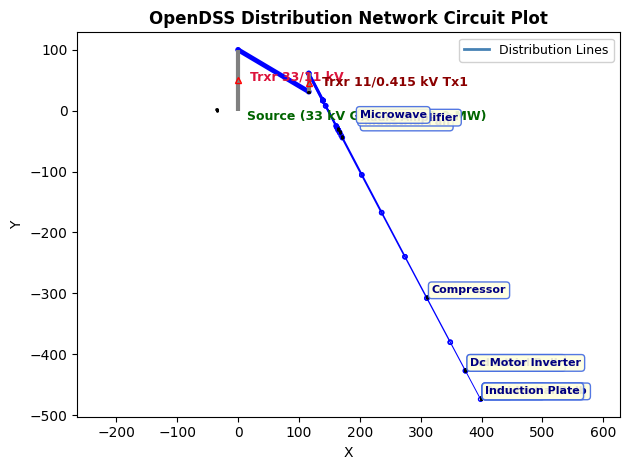

In [3]:
import matplotlib.pyplot as plt
from src.visualization.dss_circuit_plotter import plot_opendss_circuit
if "runner" not in locals() and "runner" not in globals():
    from src.simulation.runner import CoSimulationRunner
    runner = CoSimulationRunner()

print("Generating Native OpenDSS Network Circuit Plot...")
fig_circuit = plot_opendss_circuit(
    dss=runner.dss,
    use_baseline_transformers=True,
    quantity="Power",
    dots=True,
    labels=True,
    subs=True,
    save_path="src/visualization/dss_circuit_plot.png"
)
if fig_circuit:
    plt.show()


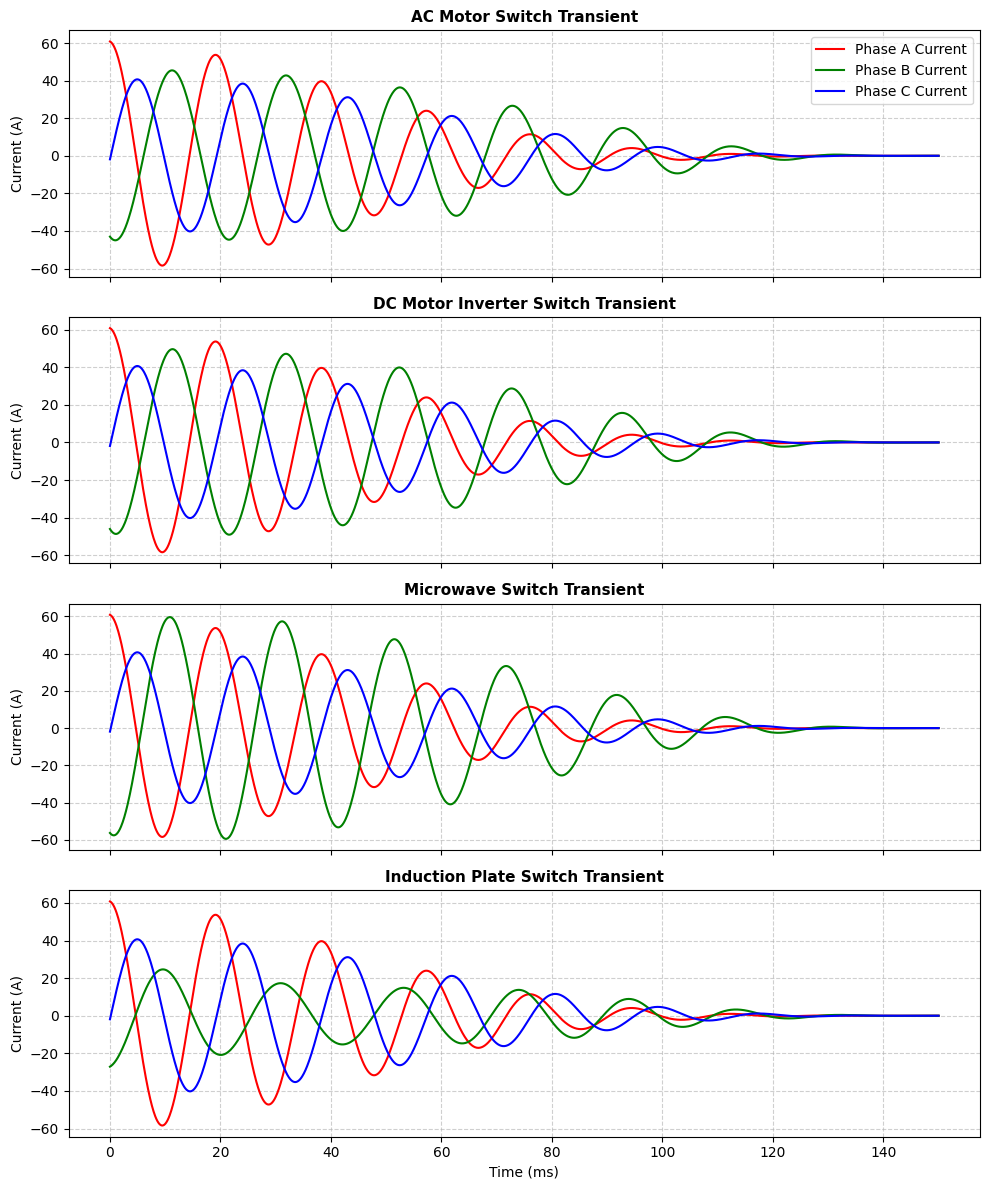

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from src.visualization.transient_waveform_plotter import simulate_and_plot_equipment_group

display(HTML("<h3>Load Circuit Switch Transients — Equipment Group 1 (AC Motor, DC Motor Inverter, Microwave, Induction Plate)</h3>"))
fig1 = simulate_and_plot_equipment_group(1)
plt.show()


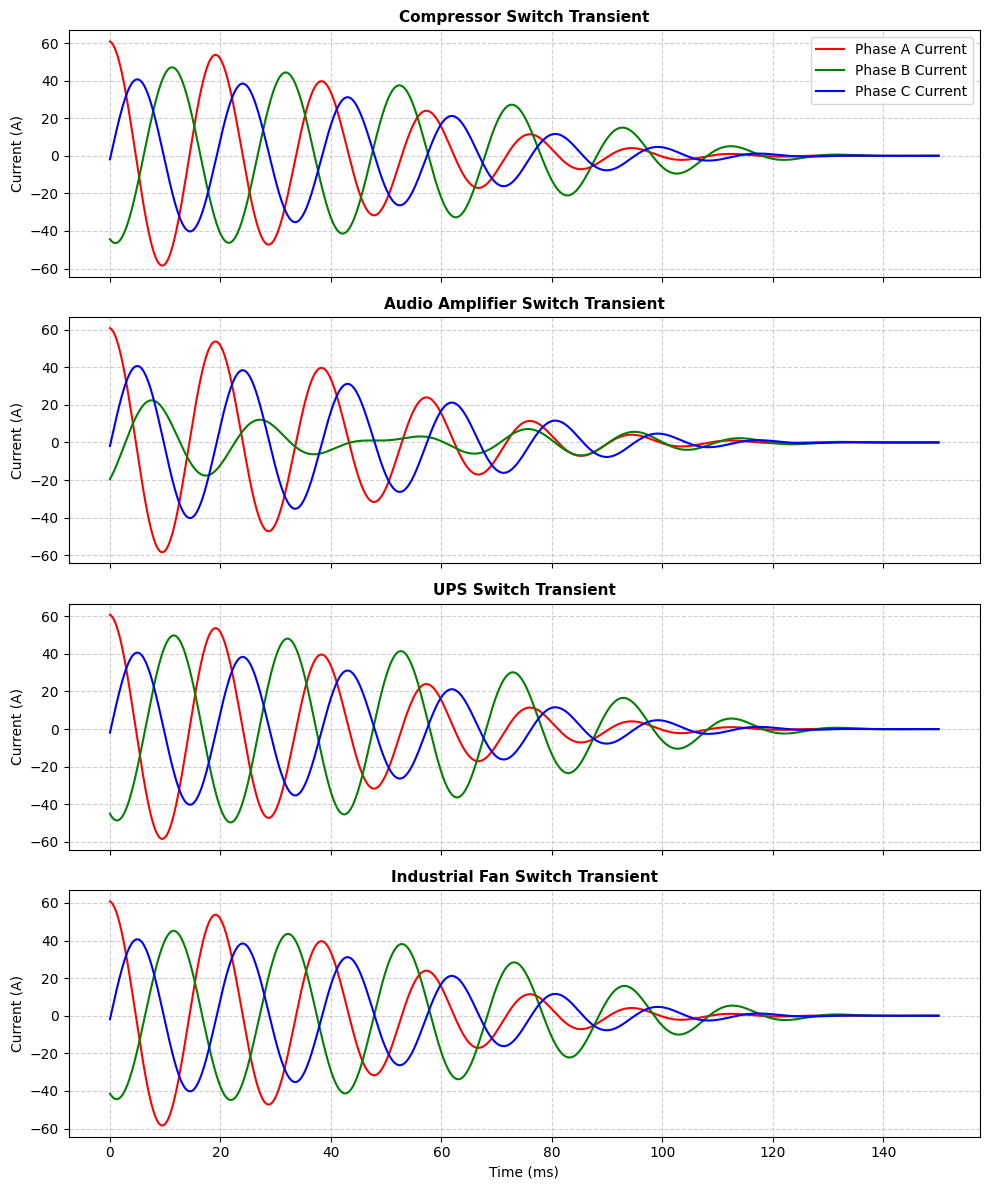

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from src.visualization.transient_waveform_plotter import simulate_and_plot_equipment_group

display(HTML("<h3>Load Circuit Switch Transients — Equipment Group 2 (Compressor, Audio Amplifier, UPS, Industrial Fan)</h3>"))
fig2 = simulate_and_plot_equipment_group(2)
plt.show()


## Stage 2: Statistical Validation & Cluster Load Allocation Error Analysis
This section evaluates Dataset 1 energy estimation errors (Baseline CLA vs Time-Adjusted CLA), followed by Q1, Q2, and Q3 statistical correlation testing across Datasets 2, 3, and 4, and computes the final transient-assisted CLA error reduction factor.

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

display(HTML("<h3>Dataset 1 (Cluster Load Allocation & Energy Estimation Dataset)</h3>"))
df_1 = pd.read_csv("src/simulation/dataset_1.csv")
display(df_1.head(20))

print("Dataset 1 Correlation & Estimation Error Testing — Baseline vs Time-Adjusted CLA Error")
unmetered_df = df_1[(df_1["consumer_type"] != "latent") & df_1["cla_estimates_kwh"].notna() & (df_1["cla_estimates_kwh"] != "")]
gt_consumer_energy = pd.to_numeric(unmetered_df["gt_consumed_energy_kwh"], errors="coerce").values
est_baseline = pd.to_numeric(unmetered_df["cla_estimates_kwh"], errors="coerce").values
est_time_adj = pd.to_numeric(unmetered_df["time_adjusted_cla_estimates_kwh"], errors="coerce").values

aggregate_gt_consumer_energy_kwh = float(np.sum(gt_consumer_energy))
aggregate_cla_estimates = float(np.sum(est_baseline))
aggregate_time_adjusted_cla_estimates = float(np.sum(est_time_adj))

baseline_cla_error_pct = float(np.abs(aggregate_gt_consumer_energy_kwh - aggregate_cla_estimates) / (aggregate_gt_consumer_energy_kwh + 1e-6)) * 100.0
time_adjusted_cla_error_pct = float(np.abs(aggregate_gt_consumer_energy_kwh - aggregate_time_adjusted_cla_estimates) / (aggregate_gt_consumer_energy_kwh + 1e-6)) * 100.0

# Mean estimation errors across individual consumer units
baseline_mean_abs_error = float(np.mean(np.abs(gt_consumer_energy - est_baseline)))
time_adjusted_mean_abs_error = float(np.mean(np.abs(gt_consumer_energy - est_time_adj)))
baseline_mean_squared_error = float(np.mean((gt_consumer_energy - est_baseline) ** 2))
time_adjusted_mean_squared_error = float(np.mean((gt_consumer_energy - est_time_adj) ** 2))
baseline_mean_pct_error = float(np.mean(np.abs(gt_consumer_energy - est_baseline) / (gt_consumer_energy + 1e-6))) * 100.0
time_adjusted_mean_pct_error = float(np.mean(np.abs(gt_consumer_energy - est_time_adj) / (gt_consumer_energy + 1e-6))) * 100.0

print(f"  Baseline Cluster Load Allocation (CLA) Aggregate Error:      {baseline_cla_error_pct:.2f}%")
print(f"  Time-Adjusted Cluster Load Allocation (CLA) Aggregate Error: {time_adjusted_cla_error_pct:.2f}%")
print(f"  Baseline CLA Mean Absolute Error across estimates:          {baseline_mean_abs_error:.4f} kWh ({baseline_mean_pct_error:.2f}% MAPE)")
print(f"  Time-Adjusted CLA Mean Absolute Error across estimates:     {time_adjusted_mean_abs_error:.4f} kWh ({time_adjusted_mean_pct_error:.2f}% MAPE)")
print(f"  Baseline CLA Mean Squared Error (MSE):                      {baseline_mean_squared_error:.4f} kWh²")
print(f"  Time-Adjusted CLA Mean Squared Error (MSE):                 {time_adjusted_mean_squared_error:.4f} kWh²")


,gt_consumer_unit_id,consumer_type,consumer_unit_source,num_loads,consumer_unit_loads,cla_assigned_weight,time_adjusted_cla_assigned_weight,gt_consumed_energy_kwh,consumer_line_losses,cla_estimates_kwh,time_adjusted_cla_estimates_kwh
0,consumer_feeder_1_f1_node1,residential_metered,"{""bus"": ""f1_node1"", ""feeder"": ""feeder_1""}",3,"[""Residential Fan"", ""Residential Fan"", ""Audio ...",NaN,NaN,0.2250,0.000053,NaN,NaN
1,consumer_feeder_1_f1_node2,commercial_metered,"{""bus"": ""f1_node2"", ""feeder"": ""feeder_1""}",3,"[""Industrial Bulb"", ""Ac Motor"", ""Compressor""]",NaN,NaN,1.7159,0.003862,NaN,NaN
2,consumer_feeder_1_f1_node3,industrial_metered,"{""bus"": ""f1_node3"", ""feeder"": ""feeder_1""}",5,"[""Industrial Bulb"", ""Dc Motor Inverter"", ""Indu...",NaN,NaN,3.1741,0.009699,NaN,NaN
3,consumer_feeder_1_f1_node4,agricultural_metered,"{""bus"": ""f1_node4"", ""feeder"": ""feeder_1""}",4,"[""Compressor"", ""Ac Motor"", ""Residential Fan"", ...",NaN,NaN,1.6444,0.002793,NaN,NaN
4,consumer_feeder_1_f1_node5,residential_metered,"{""bus"": ""f1_node5"", ""feeder"": ""feeder_1""}",4,"[""Audio Amplifier"", ""Audio Amplifier"", ""Audio ...",NaN,NaN,0.9127,0.001001,NaN,NaN
5,latent_feeder_1_f1_node5,latent,"{""bus"": ""f1_node5"", ""feeder"": ""feeder_1""}",5,"[""Ac Motor"", ""Ac Motor"", ""Residential Bulb"", ""...",NaN,NaN,NaN,0.010782,NaN,NaN
6,consumer_feeder_1_f1_node6,commercial_metered,"{""bus"": ""f1_node6"", ""feeder"": ""feeder_1""}",4,"[""Compressor"", ""Industrial Bulb"", ""Industrial ...",NaN,NaN,1.8319,0.006423,NaN,NaN
7,consumer_feeder_1_f1_node7,industrial_unmetered,"{""bus"": ""f1_node7"", ""feeder"": ""feeder_1""}",5,"[""Industrial Bulb"", ""Dc Motor Inverter"", ""Indu...",0.121911,0.132722,1.3932,0.001703,4.8544,5.2849
8,consumer_feeder_1_f1_node8,agricultural_unmetered,"{""bus"": ""f1_node8"", ""feeder"": ""feeder_1""}",5,"[""Ac Motor"", ""Industrial Bulb"", ""Ac Motor"", ""I...",0.063029,0.059905,3.4806,0.019318,2.5098,2.3854
9,consumer_feeder_1_f1_node9,residential_unmetered,"{""bus"": ""f1_node9"", ""feeder"": ""feeder_1""}",5,"[""Residential Bulb"", ""Audio Amplifier"", ""Induc...",0.039808,0.033981,0.8878,0.000848,1.5851,1.3531


Dataset 1 Correlation & Estimation Error Testing — Baseline vs Time-Adjusted CLA Error
  Baseline Cluster Load Allocation (CLA) Aggregate Error:      7.77%
  Time-Adjusted Cluster Load Allocation (CLA) Aggregate Error: 7.77%
  Baseline CLA Mean Absolute Error across estimates:          0.9179 kWh (61.10% MAPE)
  Time-Adjusted CLA Mean Absolute Error across estimates:     0.8232 kWh (50.17% MAPE)
  Baseline CLA Mean Squared Error (MSE):                      1.5500 kWh²
  Time-Adjusted CLA Mean Squared Error (MSE):                 1.6047 kWh²


### Time-Adjusted CLA Exponent Optimization (Beta Factor)
This cell computes the optimal exponent parameter $\beta^*$ that minimizes MAE over the unmetered population $U$ using:
$$s_i = w_i q_i^\beta$$
$$W_i(\beta) = \frac{w_i q_i^\beta}{\sum_{j \in U} w_j q_j^\beta}, \quad i \in U$$
$$\hat E_i(\beta) = E_U W_i(\beta)$$
$$\beta^* = \arg\min_{\beta} \frac{1}{|U|} \sum_{i \in U} \left| E_i^{GT} - \hat E_i(\beta) \right|$$
It then computes the optimal weights, allocations, and error metrics (MAE, MAPE, MSE) over $U$.

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from IPython.display import display, HTML
from src.estimator.time_adjusted_cla_estimator import TimeAdjustedCLAEstimator
if "runner" not in locals() and "runner" not in globals():
    from src.simulation.runner import CoSimulationRunner
    runner = CoSimulationRunner()
    plant_data = runner.initialize_plant_session(use_baseline_feeder=True, seed=42)
else:
    plant_data = runner.plant_data if runner.plant_data else runner.initialize_plant_session(use_baseline_feeder=True, seed=42)
registry = plant_data["registry"]

# Load Dataset 1
df_1 = pd.read_csv("src/simulation/dataset_1.csv")

# Problem 1 population definition: unmetered units U and metered units M
unmetered_df = df_1[(df_1["consumer_type"] != "latent") & df_1["consumer_type"].str.contains("unmetered")].copy()
metered_df = df_1[(df_1["consumer_type"] != "latent") & df_1["consumer_type"].str.contains("metered")].copy()

# Metered energy observations dictionary
metered_energies = {
    str(row["gt_consumer_unit_id"]): float(row["gt_consumed_energy_kwh"])
    for _, row in metered_df.iterrows()
}

# Unmetered units and metered units directly from consumer registry
unmetered_units = registry.get_unmetered_consumers()
metered_units = [u for u in registry.get_metered_consumers() if u.consumer_id in metered_energies]

# Instantiate TimeAdjustedCLAEstimator
time_cla = TimeAdjustedCLAEstimator()

# Unmetered ground truth energy vector and energy pool E_U
gt_unmetered_energies = pd.to_numeric(unmetered_df["gt_consumed_energy_kwh"], errors="coerce").values
u_ids = [u.consumer_id for u in unmetered_units]
E_U = float(np.sum(gt_unmetered_energies))

# Optimization objective function using TimeAdjustedCLAEstimator
def mae_beta_objective(beta_val):
    w_map = time_cla.weighting_function(
        unmetered_units=unmetered_units,
        metered_units=metered_units,
        metered_consumer_energies=metered_energies,
        registry=registry,
        beta=beta_val
    )
    e_hat = np.array([E_U * w_map[cid] for cid in u_ids])
    return float(np.mean(np.abs(gt_unmetered_energies - e_hat)))

# Compute optimal exponent parameter beta*
opt_res = minimize_scalar(mae_beta_objective, bounds=(0.0, 1.0), method="bounded")
beta_star = float(opt_res.x)

# Compute optimal weights and estimates using TimeAdjustedCLAEstimator at beta*
opt_weights_map = time_cla.weighting_function(
    unmetered_units=unmetered_units,
    metered_units=metered_units,
    metered_consumer_energies=metered_energies,
    registry=registry,
    beta=beta_star
)

e_hat_opt = np.array([E_U * opt_weights_map[cid] for cid in u_ids])

# Performance metrics on unmetered population U
mae_beta_star = float(np.mean(np.abs(gt_unmetered_energies - e_hat_opt)))
mape_beta_star = float(np.mean(np.abs(gt_unmetered_energies - e_hat_opt) / (gt_unmetered_energies + 1e-6))) * 100.0
mse_beta_star = float(np.mean((gt_unmetered_energies - e_hat_opt) ** 2))

display(HTML("<h3>Time-Adjusted CLA Beta Optimization & Unmetered Population Estimates</h3>"))
print(f"  Unmetered Population Size |U|:                     {len(unmetered_units)}")
print(f"  Optimal Exponent Parameter (beta*):                {beta_star:.4f}")
print(f"  Optimal Time-Adjusted CLA Mean Absolute Error:     {mae_beta_star:.4f} kWh")
print(f"  Optimal Time-Adjusted CLA MAPE:                    {mape_beta_star:.2f}%")
print(f"  Optimal Time-Adjusted CLA Mean Squared Error:      {mse_beta_star:.4f} kWh²")


  Unmetered Population Size |U|:                     13
  Optimal Exponent Parameter (beta*):                0.3962
  Optimal Time-Adjusted CLA Mean Absolute Error:     0.7890 kWh
  Optimal Time-Adjusted CLA MAPE:                    38.93%
  Optimal Time-Adjusted CLA Mean Squared Error:      1.6488 kWh²


In [8]:
import pandas as pd
from IPython.display import display, HTML
from src.statistics.q1_event_pair_analysis import run_q1_event_pair_analysis
display(HTML("<h3>Dataset 2 (Q1 Event Pair Observability Dataset — No Time Shift, Single Baseline Tx Spec)</h3>"))
df_2 = pd.read_csv("src/simulation/dataset_2.csv")
display(df_2.head(10))
display(df_2.tail(10))
print("Question 1 Statistical Testing — Event Pair Observability (Dataset 2)")
res_q1 = run_q1_event_pair_analysis()


,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_v_phase_c,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c
0,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,dc_motor_inverter,NaN,0.02,0.0,8.299388,...,"[-21.628292083740234, -25.285545349121094, -28...","[123.8840560913086, 123.64593505859375, 123.27...","[-98.36349487304688, -97.49697875976562, -96.5...","[-5.150865077972412, -2.523794412612915, 0.107...","[-60.06306076049805, -61.40617752075195, -62.6...","[47.573734283447266, 47.1100959777832, 46.5985...","[12.489325523376465, 14.296073913574219, 16.08...","[-61.9420280456543, -61.822967529296875, -61.6...","[47.573734283447266, 47.1100959777832, 46.5985...","[2.575432538986206, 1.2618972063064575, -0.053..."
1,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,microwave,NaN,0.02,0.0,8.447324,...,"[-23.101171493530273, -26.82360076904297, -30....","[124.84896850585938, 124.57240295410156, 124.1...","[-98.99722290039062, -98.08272552490234, -97.0...","[-3.527949333190918, -0.8485437035560608, 1.83...","[-61.15534591674805, -62.50287628173828, -63.7...","[47.77040481567383, 47.27885055541992, 46.7392...","[13.38434886932373, 15.223018646240234, 17.047...","[-62.42448425292969, -62.28620147705078, -62.0...","[47.77040481567383, 47.27885055541992, 46.7392...","[1.763974666595459, 0.4242718517780304, -0.916..."
2,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,induction_plate,NaN,0.02,0.0,8.016830,...,"[-43.581298828125, -46.96923828125, -50.311431...","[123.85124206542969, 123.59933471679688, 123.2...","[-77.59894561767578, -76.32804870605469, -74.9...","[-4.520075798034668, -1.881637692451477, 0.759...","[-60.90626907348633, -61.67281723022461, -62.3...","[29.79116439819336, 28.9871826171875, 28.15349...","[31.1151065826416, 32.685638427734375, 34.2234...","[-61.925621032714844, -61.79966735839844, -61....","[29.79116439819336, 28.9871826171875, 28.15349...","[2.260037899017334, 0.9408188462257385, -0.379..."
3,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,compressor,NaN,0.02,0.0,8.266100,...,"[-25.024181365966797, -28.708118438720703, -32...","[124.6334228515625, 124.3639907836914, 123.965...","[-96.81474304199219, -95.86740112304688, -94.8...","[-3.8244106769561768, -1.155429482460022, 1.51...","[-60.963409423828125, -62.28440475463867, -63....","[46.943946838378906, 46.44317626953125, 45.895...","[14.0194673538208, 15.841222763061523, 17.6483...","[-62.31671142578125, -62.1819953918457, -61.98...","[46.943946838378906, 46.44317626953125, 45.895...","[1.9122053384780884, 0.577714741230011, -0.757..."
4,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,audio_amplifier,NaN,0.02,0.0,7.868377,...,"[-49.88075256347656, -53.10527801513672, -56.2...","[123.12145233154297, 122.91622924804688, 122.5...","[-69.79026794433594, -68.42707061767578, -66.9...","[-6.547854900360107, -3.9643383026123047, -1.3...","[-60.52391815185547, -61.03829574584961, -61.4...","[22.160972595214844, 21.233707427978516, 20.28...","[38.36769104003906, 39.80948257446289, 41.2109...","[-61.560726165771484, -61.45811462402344, -61....","[22.160972595214844, 21.233707427978516, 20.28...","[3.2739274501800537, 1.9821691513061523, 0.687..."
5,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,ups,NaN,0.02,0.0,8.363263,...,"[-24.86487579345703, -28.583053588867188, -32....","[124.76730346679688, 124.48002624511719, 124.0...","[-97.662353515625, -96.70697021484375, -95.653...","[-3.030712127685547, -0.34357333183288574, 2.3...","[-6

,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_v_phase_c,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c
98,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,7.949984,...,"[-71.923095703125, -74.88175964355469, -77.764...","[123.44754791259766, 123.23819732666016, 122.9...","[-49.251220703125, -47.48249053955078, -45.664...","[-6.402076244354248, -3.8085906505584717, -1.2...","[-59.415035247802734, -60.70917510986328, -61....","[3.201038360595703, 1.904296875, 0.60503005981...","[58.522735595703125, 59.71480178833008, 60.845...","[-61.72377395629883, -61.61909866333008, -61.4...","[3.201038360595703, 1.904296875, 0.60503005981...","[3.201038122177124, 1.9042953252792358, 0.6050..."
99,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,8.017158,...,"[-73.4852066040039, -76.46517944335938, -79.36...","[123.8470458984375, 123.6077880859375, 123.239...","[-97.04928588867188, -96.15731048583984, -95.1...","[-5.094194412231445, -2.4668521881103516, 0.16...","[-61.92352294921875, -61.803897857666016, -61....","[46.01509094238281, 45.52172088623047, 44.9820...","[59.376426696777344, 60.570465087890625, 61.70...","[-61.92352294921875, -61.80389404296875, -61.6...","[46.01509094238281, 45.52172088623047, 44.9820...","[2.5470972061157227, 1.2334260940551758, -0.08..."
100,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,8.041717,...,"[-26.160781860351562, -29.887496948242188, -33...","[124.5324935913086, 124.22476196289062, 123.78...","[-46.90009689331055, -45.00865173339844, -43.0...","[-2.0707430839538574, 0.6296276450157166, 3.33...","[-62.26624298095703, -62.11238098144531, -61.8...","[1.035369873046875, -0.3148155212402344, -1.66...","[15.696948051452637, 17.52379608154297, 19.334...","[-62.2662467956543, -62.11238098144531, -61.89...","[1.035369873046875, -0.3148155212402344, -1.66...","[1.0353715419769287, -0.3148138225078583, -1.6..."
101,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.02,0.0,8.316431,...,"[-75.09639739990234, -78.09033203125, -81.0053...","[123.83292388916016, 123.55807495117188, 123.1...","[-96.67558288574219, -95.73471069335938, -94.6...","[-3.4749650955200195, -0.8168998956680298, 1.8...","[-60.70808792114258, -61.99295425415039, -63.2...","[45.79545593261719, 45.278141021728516, 44.714...","[60.178977966308594, 61.3705940246582, 62.4989...","[-61.91646194458008, -61.77903747558594, -61.5...","[45.79545593261719, 45.278141021728516, 44.714...","[1.7374825477600098, 0.4084499478340149, -0.92..."
102,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.02,0.0,7.848107,...,"[-17.533912658691406, -20.995683670043945, -24...","[121.50895690917969, 121.38451385498047, 121.1...","[-96.34693908691406, -95.62358856201172, -94.8...","[-10.01107406616211, -7.529412269592285, -5.03...","[-60.75447463989258, -60.69225311279297, -60.5...","[45.81278610229492, 45.4030647277832, 44.94721...","[11.326163291931152, 13.026859283447266, 14.71...","[-60.754478454589844, -60.692256927490234, -60...","[45.81278610229492, 45.4030647277832, 44.94721...","[5.005537033081055, 3.7647061347961426, 2.5194..."
103,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}"

Question 1 Statistical Testing — Event Pair Observability (Dataset 2)
--- Running Question 1 Analysis: Event Pair Observability (Dataset 2) ---
Waveform Pearson Correlation (Dataset 2): Mean Correlation = 0.4399, Std = 0.1680
  Residual/Composed Magnitude Ratio: 0.3174, Total Discount Factor = 0.3352
  Per-Column Correlation Vector: [0.4206, 0.2645, 0.3603, 0.6648, 0.2645, 0.6648]
Overall Dataset 2 (N=108): Mean V_res = 11.218888, Mean I_res = 8.288529


In [9]:
import pandas as pd
from IPython.display import display, HTML
from src.statistics.q2_time_shift_analysis import run_q2_time_shift_analysis
display(HTML("<h3>Dataset 3 (Q2 Time Shift Operation Dataset — Single Baseline Tx Spec)</h3>"))
df_3 = pd.read_csv("src/simulation/dataset_3.csv")
display(df_3.head(10))
display(df_3.tail(10))
print("Question 2 Statistical Testing — Time Shift Operation Variation (Dataset 3)")
res_q2 = run_q2_time_shift_analysis()


,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_v_phase_c,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c
0,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,dc_motor_inverter,NaN,0.0250,0.0050,8.387987,...,"[-37.028690338134766, -41.20729064941406, -45....","[123.8840560913086, 123.64593505859375, 123.27...","[-93.79252624511719, -92.52847290039062, -91.1...","[-5.150865077972412, -2.523794412612915, 0.107...","[-70.1775131225586, -71.63455200195312, -73.02...","[43.30707550048828, 42.47167205810547, 41.5922...","[26.870439529418945, 29.162874221801758, 31.42...","[-61.9420280456543, -61.822967529296875, -61.6...","[43.30707550048828, 42.47167205810547, 41.5922...","[2.575432538986206, 1.2618972063064575, -0.053..."
1,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,microwave,NaN,0.0254,0.0054,8.567539,...,"[-38.6859130859375, -42.97260284423828, -47.22...","[124.84896850585938, 124.57240295410156, 124.1...","[-94.47847747802734, -93.08224487304688, -91.5...","[-3.527949333190918, -0.8485437035560608, 1.83...","[-71.41678619384766, -72.84071350097656, -74.1...","[43.538787841796875, 42.60041809082031, 41.617...","[27.892868041992188, 30.255111694335938, 32.58...","[-62.42448425292969, -62.28620147705078, -62.0...","[43.538787841796875, 42.60041809082031, 41.617...","[1.763974666595459, 0.4242718517780304, -0.916..."
2,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,induction_plate,NaN,0.0258,0.0058,8.027352,...,"[-52.302215576171875, -56.021453857421875, -59...","[123.85124206542969, 123.59933471679688, 123.2...","[-75.39042663574219, -73.8117446899414, -72.15...","[-4.520075798034668, -1.881637692451477, 0.759...","[-67.3470230102539, -68.13694763183594, -68.85...","[27.606327056884766, 26.497947692871094, 25.36...","[39.74069595336914, 41.63899612426758, 43.4963...","[-61.925621032714844, -61.79966735839844, -61....","[27.606327056884766, 26.497947692871094, 25.36...","[2.260037899017334, 0.9408188462257385, -0.379..."
3,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,compressor,NaN,0.0263,0.0063,8.372984,...,"[-39.61748123168945, -43.871437072753906, -48....","[124.6334228515625, 124.3639907836914, 123.965...","[-93.92601013183594, -92.38352966308594, -90.7...","[-3.8244106769561768, -1.155429720878601, 1.51...","[-72.11778259277344, -73.41580963134766, -74.6...","[44.18170928955078, 43.113304138183594, 41.999...","[27.936073303222656, 30.3024959564209, 32.6409...","[-62.31671142578125, -62.1819953918457, -61.98...","[44.18170928955078, 43.113304138183594, 41.999...","[1.9122053384780884, 0.5777148604393005, -0.75..."
4,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,audio_amplifier,NaN,0.0267,0.0067,7.875825,...,"[-55.79555892944336, -59.25642395019531, -62.6...","[123.12145233154297, 122.91622924804688, 122.5...","[-69.12775421142578, -67.50337219238281, -65.8...","[-6.547854900360107, -3.9643383026123047, -1.3...","[-65.7328109741211, -66.22268676757812, -66.64...","[21.504077911376953, 20.317737579345703, 19.10...","[44.23487091064453, 45.911067962646484, 47.541...","[-61.560726165771484, -61.45811462402344, -61....","[21.504077911376953, 20.317737579345703, 19.10...","[3.2739274501800537, 1.9821691513061523, 0.687..."
5,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,ups,NaN,0.0271,0.0071,8.478567,...,"[-40.09638595581055, -44.38671875, -48.6364517...","[124.76730346679688, 124.48002624511719, 124.0...","[-96.5928955078125, -94.93487548828125, -93.17...","[-3.030712127685547, -0.3

,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_v_phase_c,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c
98,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.0662,0.0462,7.722472,...,"[-71.923095703125, -74.88175964355469, -77.764...","[123.44754791259766, 123.23819732666016, 122.9...","[-49.251220703125, -47.48249053955078, -45.664...","[-6.402076244354248, -3.8085906505584717, -1.2...","[-75.10240173339844, -74.58488464355469, -73.9...","[3.201038360595703, 1.904296875, 0.60503005981...","[58.522735595703125, 59.71480178833008, 60.845...","[-61.72377395629883, -61.61909866333008, -61.4...","[3.201038360595703, 1.904296875, 0.60503005981...","[3.201038122177124, 1.9042953252792358, 0.6050..."
99,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.0666,0.0466,7.786067,...,"[-73.4852066040039, -76.46517944335938, -79.36...","[123.8470458984375, 123.6077880859375, 123.239...","[-44.542911529541016, -42.11457824707031, -39....","[-5.094194412231445, -2.4668521881103516, 0.16...","[-61.92352294921875, -61.803897857666016, -61....","[-1.0609359741210938, -2.931903839111328, -4.8...","[59.376426696777344, 60.570465087890625, 61.70...","[-61.92352294921875, -61.80389404296875, -61.6...","[-1.0609359741210938, -2.931903839111328, -4.8...","[2.5470972061157227, 1.2334260940551758, -0.08..."
100,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.0671,0.0471,7.942529,...,"[-96.48831176757812, -99.64785766601562, -102....","[124.5324935913086, 124.22476196289062, 123.78...","[-46.90009689331055, -45.00865173339844, -43.0...","[-2.0707430839538574, 0.6296276450157166, 3.33...","[-62.26624298095703, -62.11238098144531, -61.8...","[1.035369873046875, -0.3148155212402344, -1.66...","[78.75875854492188, 80.0770034790039, 81.31184...","[-62.2662467956543, -62.11238098144531, -61.89...","[1.035369873046875, -0.3148155212402344, -1.66...","[1.0353715419769287, -0.3148138225078583, -1.6..."
101,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.0675,0.0475,7.890172,...,"[-75.09639739990234, -78.09033203125, -81.0053...","[123.83292388916016, 123.55807495117188, 123.1...","[-42.068851470947266, -39.64521789550781, -37....","[-3.4749650955200195, -0.8168998956680298, 1.8...","[-74.48286437988281, -73.94810485839844, -73.3...","[-3.1591339111328125, -5.005863189697266, -6.8...","[60.178977966308594, 61.3705940246582, 62.4989...","[-61.91646194458008, -61.77903747558594, -61.5...","[-3.1591339111328125, -5.005863189697266, -6.8...","[1.7374825477600098, 0.4084499478340149, -0.92..."
102,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.0679,0.0479,7.494815,...,"[-85.59748840332031, -88.62935638427734, -91.5...","[121.50895690917969, 121.38451385498047, 121.1...","[-45.94308853149414, -43.74778366088867, -41.5...","[-10.01107406616211, -7.529412269592285, -5.03...","[-60.75447463989258, -60.69225311279297, -60.5...","[0.6171340942382812, -1.1122322082519531, -2.8...","[72.34032440185547, 73.65568542480469, 74.8944...","[-60.754478454589844, -60.692256927490234, -60...","[0.6171340942382812, -1.1122322082519531, -2.8...","[5.005537033081055, 3.7647061347961426, 2.5194..."
103,"{""bus"": ""feeder1_head"", ""l

Question 2 Statistical Testing — Time Shift Operation Variation (Dataset 3)
--- Running Question 2 Analysis: Time Shift Operation Variation (Dataset 3) ---
Waveform Pearson Correlation (Dataset 3): Mean Correlation = 0.3158, Std = 0.2212
  Residual/Composed Magnitude Ratio: 0.3650, Total Discount Factor = 0.3828
  Per-Column Correlation Vector: [0.2428, 0.0927, 0.2319, 0.6172, 0.0927, 0.6172]
Overall Dataset 3 Time Shift (N_sim=0, N_shift=108):
  Simultaneous: Mean V_res = 0.000000, Mean I_res = 0.000000
  Time-Shifted: Mean V_res = 15.274317, Mean I_res = 9.721547


In [10]:
import pandas as pd
from IPython.display import display, HTML
from src.statistics.q3_transformer_spec_analysis import run_q3_transformer_spec_analysis
display(HTML("<h3>Dataset 4 (Q3 Transformer Specification Dataset — Fixed Time Shift = 0)</h3>"))
df_4 = pd.read_csv("src/simulation/dataset_4.csv")
display(df_4.head(10))
display(df_4.tail(10))
print("Question 3 Statistical Testing — Transformer Specification Effect (Dataset 4)")
res_q3 = run_q3_transformer_spec_analysis()


,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c,gt_feeder_id
0,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,dc_motor_inverter,NaN,0.02,0.0,8.225344,...,"[123.68639373779297, 123.49105072021484, 123.1...","[-98.62312316894531, -97.81665802001953, -96.9...","[-7.069353103637695, -4.483401298522949, -1.89...","[-59.23707962036133, -60.586463928222656, -61....","[47.73215866088867, 47.2982292175293, 46.81625...","[11.504911422729492, 13.288235664367676, 15.05...","[-61.843196868896484, -61.74552536010742, -61....","[47.73215866088867, 47.2982292175293, 46.81625...","[3.5346765518188477, 2.2417006492614746, 0.945...",feeder_1
1,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,microwave,NaN,0.02,0.0,8.281150,...,"[124.0194091796875, 123.83635711669922, 123.52...","[-98.17837524414062, -97.3779067993164, -96.47...","[-7.6711907386779785, -5.089446544647217, -2.5...","[-59.23469543457031, -60.55782699584961, -61.8...","[46.9339485168457, 46.48820495605469, 45.99522...","[12.300514221191406, 14.068992614746094, 15.82...","[-62.00970458984375, -61.91817855834961, -61.7...","[46.9339485168457, 46.48820495605469, 45.99522...","[3.8355953693389893, 2.5447232723236084, 1.250...",feeder_2
2,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,induction_plate,NaN,0.02,0.0,8.030978,...,"[122.88379669189453, 122.6408920288086, 122.27...","[-82.80661010742188, -81.6614761352539, -80.43...","[-4.8045525550842285, -2.1928532123565674, 0.4...","[-60.19485855102539, -61.10975646972656, -61.9...","[34.332855224609375, 33.627342224121094, 32.88...","[25.862009048461914, 27.482421875, 29.07566070...","[-61.441898345947266, -61.3204460144043, -61.1...","[34.332855224609375, 33.627342224121094, 32.88...","[2.4022762775421143, 1.0964266061782837, -0.21...",feeder_3
3,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,compressor,NaN,0.02,0.0,8.026968,...,"[122.70734405517578, 122.54534149169922, 122.2...","[-96.40503692626953, -95.61418914794922, -94.7...","[-8.458394050598145, -5.9206061363220215, -3.3...","[-58.27201461791992, -59.59360122680664, -60.8...","[46.81846237182617, 46.39554977416992, 45.9255...","[11.453551292419434, 13.198053359985352, 14.93...","[-61.35367202758789, -61.27267074584961, -61.1...","[46.81846237182617, 46.39554977416992, 45.9255...","[4.229197025299072, 2.9603030681610107, 1.6878...",feeder_1
4,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,audio_amplifier,NaN,0.02,0.0,7.532337,...,"[122.05028533935547, 121.97367095947266, 121.7...","[-67.8676528930664, -66.58834838867188, -65.24...","[-12.254758834838867, -9.804187774658203, -7.3...","[-59.39775085449219, -59.85336685180664, -60.2...","[20.88860321044922, 19.97425079345703, 19.0392...","[38.512855529785156, 39.8829460144043, 41.2124...","[-61.025142669677734, -60.98683547973633, -60....","[20.88860321044922, 19.97425079345703, 19.0392...","[6.127379417419434, 4.902093887329102, 3.67120...",feeder_2
5,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}",{},ac_motor,NaN,0.02,ups,NaN,0.02,0.0,8.240735,...,"[123.09070587158203, 122.85086059570312, 122.4...","[-98.28242492675781, -97.42788696289062, -96.4...","[-4.970118999481201, -2.3570406436920166, 0.25...","[-59.698856353759766, -61.062469482421875, -62...","[48.16557312011719, 47.71990203857422, 47.2257...","[11.533289909362793, 13.342564582824707, 15.13...","[-61.545352935791016, -61.42543029785156, -61....","[48.16557312011719, 47.71990203857422, 47.2257...","[2.4850594997406006, 1.178

,load_source,fault_info,gt_event_1_equipment_type,gt_event_1_fault_type,gt_event_1_start_timestamp_s,gt_event_2_equipment_type,gt_event_2_fault_type,gt_event_2_start_timestamp_s,gt_time_offset_s,voltage_magnitude,...,obs_composed_event_i_phase_a,obs_composed_event_i_phase_b,obs_composed_event_i_phase_c,obs_residual_v_phase_a,obs_residual_v_phase_b,obs_residual_v_phase_c,obs_residual_i_phase_a,obs_residual_i_phase_b,obs_residual_i_phase_c,gt_feeder_id
98,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,8.074875,...,"[122.88359832763672, 122.63591766357422, 122.2...","[-49.43992233276367, -47.66464614868164, -45.8...","[-4.587465286254883, -1.9716098308563232, 0.64...","[-59.766544342041016, -61.09693145751953, -62....","[2.293731689453125, 0.9858055114746094, -0.323...","[59.1480712890625, 60.33216094970703, 61.45405...","[-61.44179916381836, -61.31795883178711, -61.1...","[2.293731689453125, 0.9858055114746094, -0.323...","[2.2937326431274414, 0.9858049154281616, -0.32...",feeder_3
99,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,7.838124,...,"[122.48167419433594, 122.30059051513672, 121.9...","[-96.53883361816406, -95.7330322265625, -94.83...","[-7.562122344970703, -5.01212215423584, -2.455...","[-61.24083709716797, -61.150291442871094, -60....","[45.83287811279297, 45.38228225708008, 44.8855...","[57.459774017333984, 58.64423370361328, 59.768...","[-61.24083709716797, -61.15029525756836, -60.9...","[45.83287811279297, 45.38228225708008, 44.8855...","[3.7810611724853516, 2.50606107711792, 1.22792...",feeder_1
100,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LG,0.02,0.0,7.229419,...,"[120.11312866210938, 120.14533233642578, 120.0...","[-53.4646110534668, -51.97689437866211, -50.43...","[-16.950376510620117, -14.632424354553223, -12...","[-60.05656433105469, -60.07266616821289, -60.0...","[8.475189208984375, 7.316211700439453, 6.14914...","[9.1253662109375, 10.719751358032227, 12.30435...","[-60.05656433105469, -60.07266616821289, -60.0...","[8.475189208984375, 7.316211700439453, 6.14914...","[8.475188255310059, 7.316212177276611, 6.14914...",feeder_2
101,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.02,0.0,8.053552,...,"[121.69959259033203, 121.51395416259766, 121.2...","[-97.36201477050781, -96.58274841308594, -95.7...","[-7.254795551300049, -4.716113090515137, -2.17...","[-58.13996887207031, -59.46918869018555, -60.7...","[47.00480270385742, 46.582481384277344, 46.112...","[57.22239303588867, 58.39892578125, 59.5152702...","[-60.849796295166016, -60.75697708129883, -60....","[47.00480270385742, 46.582481384277344, 46.112...","[3.6273977756500244, 2.3580565452575684, 1.085...",feeder_3
102,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.02,0.0,8.153828,...,"[124.19578552246094, 123.9737777709961, 123.62...","[-97.49811553955078, -96.62823486328125, -95.6...","[-5.923428058624268, -3.3043055534362793, -0.6...","[-62.09789276123047, -61.98688888549805, -61.8...","[46.24376678466797, 45.76101303100586, 45.2317...","[13.738579750061035, 15.521077156066895, 17.28...","[-62.09789276123047, -61.98688888549805, -61.8...","[46.24376678466797, 45.76101303100586, 45.2317...","[2.961714029312134, 1.6521527767181396, 0.3403...",feeder_1
103,"{""bus"": ""feeder1_head"", ""line"": ""feeder1_head""}","{""fault_id"": ""joint_fault"", ""bus"": ""mv_feeder_...",industrial_fan,NaN,0.02,NaN,LL,0.02,0.0,7.539023,...,"[119.63878631591797, 119.67179107666016, 119.5...","[-53.28086853027344, -51.80005645751953, -50.2...","[-16.92580795

Question 3 Statistical Testing — Transformer Specification Effect (Dataset 4)
--- Running Question 3 Analysis: Transformer Specification Effect (Dataset 4) ---
Waveform Pearson Correlation (Dataset 4): Mean Correlation = 0.4364, Std = 0.1705
  Residual/Composed Magnitude Ratio: 0.3177, Total Discount Factor = 0.3355
  Per-Column Correlation Vector: [0.4166, 0.2579, 0.3569, 0.6645, 0.2579, 0.6645]
Overall Dataset 4 Transformer Spec Effect (N=108): Mean V_res = 11.059375, Mean I_res = 8.177067


### Transient-Assisted CLA Error Reduction Factor
This cell computes the overall mean dissimilarity and error reduction factor achieved by applying transient-assisted error correction to time-adjusted CLA.

In [11]:
import numpy as np

mean_waveform_corr = float(np.mean([
    res_q1.get("mean_waveform_correlation", 0.0),
    res_q2.get("mean_waveform_correlation", 0.0),
    res_q3.get("mean_waveform_correlation", 0.0)
]))

S = mean_waveform_corr
mean_dissimilarity = float(1.0 - S)

# Transient-assisted error reduction factor directly from waveform dissimilarity D
error_reduction_factor = mean_dissimilarity
corrected_time_adj_error_pct = float(time_adjusted_cla_error_pct * (1.0 - error_reduction_factor))

print(f"Overall Average Pearson Correlation (S = mean_waveform_corr): {S:.4f}")
print(f"Overall Mean Dissimilarity (D = 1 - S):                     {mean_dissimilarity:.4f}")
print(f"Transient-Assisted CLA Error Reduction Factor:             {error_reduction_factor:.4f} ({error_reduction_factor:.2%})")
print(f"Corrected Time-Adjusted CLA Error:                         {corrected_time_adj_error_pct:.2f}%")


Overall Average Pearson Correlation (S = mean_waveform_corr): 0.3974
Overall Mean Dissimilarity (D = 1 - S):                     0.6026
Transient-Assisted CLA Error Reduction Factor:             0.6026 (60.26%)
Corrected Time-Adjusted CLA Error:                         3.09%
